In [46]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import scipy.stats as stats
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

In [82]:
df = pd.read_csv(r"C:\Skills\Machine Learning\ML main\Understanding Data\Titanic-Dataset.csv",usecols=['Age','Fare','Survived'])

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [84]:
# removing missing values from age 
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\singl\AppData\Local\Temp\ipykernel_11560\414588443.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [86]:
# Step 1 - Doing train test split of the data 
x_train , x_test ,y_train , y_test = train_test_split(df.iloc[:,1:],df['Survived'],random_state=42,test_size=0.2)

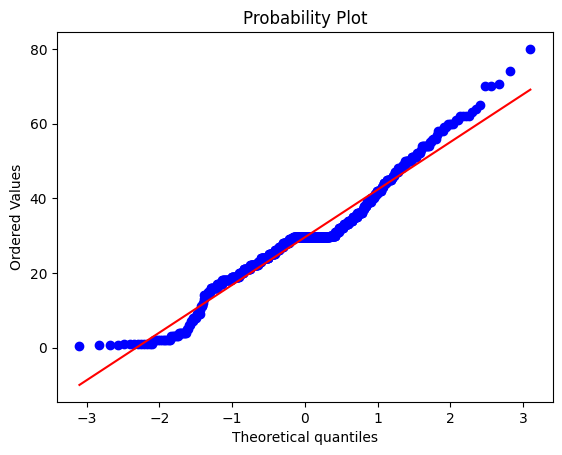

In [87]:
# ploting age pdf now  
stats.probplot(x_train['Age'],plot=plt)
plt.show()

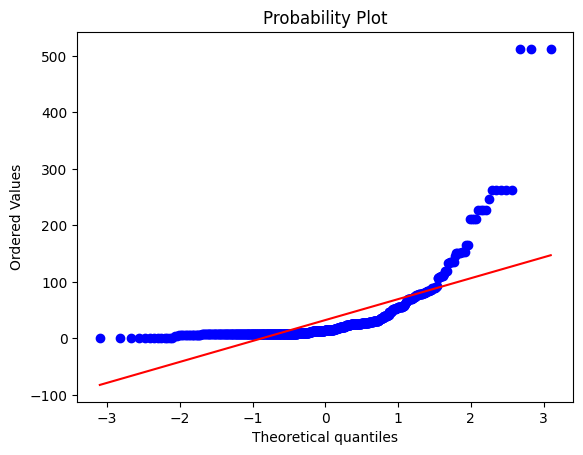

In [88]:
# for fare 
stats.probplot(x_train['Fare'],plot=plt)
plt.show()

In [89]:
# cheking model wihtout the transformer and training just like that 
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [91]:
pred1 = clf1.predict(x_test)
pred2 = clf2.predict(x_test)

In [92]:
print('Logistic Regression = ',accuracy_score(y_test,pred1))
print('Decision tree = ',accuracy_score(y_test,pred2))

Logistic Regression =  0.6480446927374302
Decision tree =  0.6703910614525139


In [94]:
# now we will transform and then check 
transform = FunctionTransformer(func=np.log1p)

In [95]:
x_train_trf = transform.fit_transform(x_train)
x_test_trf = transform.transform(x_test)

In [96]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_train_trf,y_train)
clf2.fit(x_train_trf,y_train)

pred1 = clf1.predict(x_test_trf)
pred2 = clf2.predict(x_test_trf)

print('Logistic Regression = ',accuracy_score(y_test,pred1))
print('Decision tree = ',accuracy_score(y_test,pred2))

Logistic Regression =  0.6815642458100558
Decision tree =  0.6815642458100558


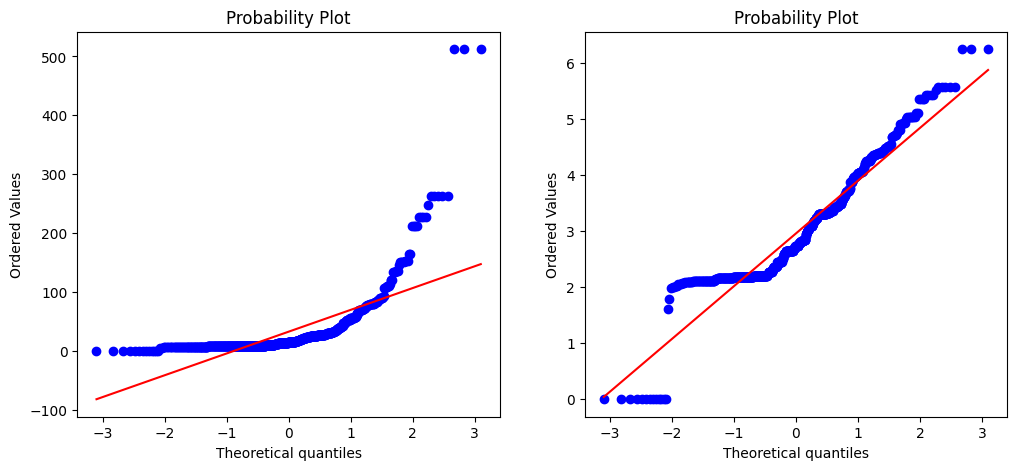

In [103]:
# now we will check Fare before and after qq plot 
plt.figure(figsize=(12,5))
plt.subplot(121)
stats.probplot(x_train['Fare'],plot=plt)
plt.subplot(122)
stats.probplot(x_train_trf['Fare'],plot=plt)
plt.show()